Giulio Tesei
giulio.tesei@mau.se

In [3]:
import os
os.environ["FMDL_DATA_PATH"] = "/Users/giulio.tesei/BilayerData"

In [4]:
import numpy as np
import json
from scipy import constants
import subprocess
from scipy.stats import pearsonr

# Download code for blocking analysis
try:
    subprocess.run(['wget','-O','main.py','https://raw.githubusercontent.com/fpesceKU/BLOCKING/v0.1/main.py'])
    subprocess.run(['wget','-O','block_tools.py','https://raw.githubusercontent.com/fpesceKU/BLOCKING/v0.1/block_tools.py'])
except FileNotFoundError:
    subprocess.run(['curl','-o','main.py','https://raw.githubusercontent.com/fpesceKU/BLOCKING/v0.1/main.py'])
    subprocess.run(['curl','-o','block_tools.py','https://raw.githubusercontent.com/fpesceKU/BLOCKING/v0.1/block_tools.py'])

from main import BlockAnalysis
def autoblock(cv, multi=1):
    block = BlockAnalysis(cv, multi=multi)
    block.SEM()    
    return block.sem, int(block.bs)

# set colors

import matplotlib as mpl
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

hexcolors = [
    "#D1B8D7", "#AE76A3", "#882E72", "#1965B0", "#5289C7",
    "#7BAFDE", "#4EB265", "#90C987", "#CAE0AB", "#F7F056",
    "#F6C141", "#F1932D", "#E8601C", "#DC050C", "#777777",
]
colornames = [
    "purple1", "purple2", "purple3", "blue1", "blue2", "blue3",
    "green1", "green2", "green3", "yellow1", "yellow2", "orange1",
    "orange2", "red", "grey",
]
rnb_colors = dict(zip(colornames, hexcolors))

gradient_colors = [
    rnb_colors["blue2"],
    rnb_colors["green1"],
    rnb_colors["yellow2"],
    rnb_colors["red"],
]
cmap = mpl.colors.LinearSegmentedColormap.from_list("temp_gradient", gradient_colors, N=256)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  3690  100  3690    0     0  69410      0 --:--:-- --:--:-- --:--:-- 69622
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  3049  100  3049    0     0  88461      0 --:--:-- --:--:-- --:--:-- 89676


In [5]:
import fairmd
import h5py
import glob
from datetime import datetime
from fairmd.lipids.core import *
#from fairmd.lipids.databankLibrary import *
from fairmd.lipids.api import *
#check DatabankLib for tools on eq times, composition, also has a run utility etc
#utilize the smiles?
from fairmd.lipids.molecules import Lipid, Molecule, NonLipid
import pandas as pd
# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
from fairmd.lipids import (
    FMDL_DATA_PATH,
    FMDL_SIMU_PATH,
    RCODE_COMPUTED,
    RCODE_ERROR,
    RCODE_SKIPPED,
)
import warnings
warnings.simplefilter("always")
from numba import jit

fairmd-lipids 1.5.4.dev15+gc501533c6 by NMRlipids Open Collaboration - GPL-3.0-or-later


/Users/giulio.tesei/miniconda3/envs/fairmd-lipids/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FAIRMD Lipids is initialized from the folder: /Users/giulio.tesei/BilayerData
---------------------------------------------------------------


/Users/giulio.tesei/miniconda3/envs/fairmd-lipids/lib/python3.10/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [6]:
def block_means(array, block_size):
    """Calculates averages over blocks"""
    n_blocks = len(array) // block_size
    return np.array([array[i*block_size:(i+1)*block_size].mean() for i in range(n_blocks)])

def _get_2d_array(system: System, fname: str) -> np.ndarray:
    """Get whatever 2D array stored in the DB.

    :param system: Simulation object
    :param fname: Filename (str)
    :return: numpy table
    """
    fn = os.path.join(
        FMDL_SIMU_PATH,
        system["path"],
        fname,
    )
    try:
        with open(fn) as json_file:
            sim_ff_data = json.load(json_file)
    except FileNotFoundError as e:
        msg = "The form-factor data is missing for system#{}.".format(system["ID"])
        raise FileNotFoundError(msg) from e
    except json.JSONDecodeError as e:
        msg = "The form-factor data for system#{} is invalid.".format(system["ID"])
        raise ValueError(msg) from e
    return np.array(sim_ff_data)

def get_ApL_data(system: System, blocksize: float | None = None) -> np.ndarray:  # noqa: N802 (API name)
    """
    Return Area-per-lipid data as a numpy array (block-averaging possible).

    :param system: Simulation object
    :param blocksize: Averaged t-series by <blocksize> ps

    :return: Array (t, value) with blocksize step.
    """
    df = _get_2d_array(system, "apl.json")
    if blocksize is not None:
        df = block_average_time_series(df, blocksize)
    return df

def get_apl_stretching_modulus(system: System) -> float:  
    """
    Calculate stretching modulus for a system.

    :param system: Simulation object.

    :return: stretching modulus (mN/m)
    """
    df = get_ApL_data(system)
    kBT = 1.380649e-23*system._store['TEMPERATURE']
    N_lipids = system.n_lipids

    apl = df[:, 1]

    mean_apl = apl.mean()
    mean_apl2 = (apl**2).mean()
    
    mean_apl_err, bs = autoblock(apl)
    mean_apl2_err, bs2 = autoblock(apl**2)
    
    bs_common = max(bs, bs2)
    
    mean_apl_blocks = block_means(apl, bs_common)
    mean_apl2_blocks = block_means(apl**2, bs_common)
    
    n_blocks = len(mean_apl_blocks)
    
    mean_apl_err = np.std(mean_apl_blocks, ddof=1) / np.sqrt(n_blocks)
    mean_apl2_err = np.std(mean_apl2_blocks, ddof=1) / np.sqrt(n_blocks)

    cov_mean_apl_apl2 = np.cov(mean_apl_blocks, mean_apl2_blocks, ddof=1)[0, 1] / n_blocks
    
    var_apl = mean_apl2 - mean_apl**2
    
    C = 2 * kBT / N_lipids * 1e23
    
    stretching = C * mean_apl / var_apl
    
    dK_dm = C * (mean_apl2 + mean_apl**2) / var_apl**2
    dK_dq = -C * mean_apl / var_apl**2
    
    stretching_err = np.sqrt(dK_dm**2 * mean_apl_err**2 + dK_dq**2 * mean_apl2_err**2 
                             + 2 * dK_dm * dK_dq * cov_mean_apl_apl2)
    
    return mean_apl, mean_apl_err, stretching, stretching_err

def add_system_to_hdf5(h5, result):
    """
    Add one system to an HDF5 database.

    Parameters
    ----------
    h5 : h5py.File
        Open HDF5 file.

    result : dict
        Dictionary containing one processed system.
    """

    system = result["system"]

    sys_grp = h5.require_group(f"systems/{system['ID']}")

    #
    # ---- Metadata ----------------------------------------------------------
    #
    meta = sys_grp.require_group("metadata")

    meta.attrs["system_id"] = system["ID"]
    meta.attrs["temperature"] = system.get("TEMPERATURE", np.nan)
    meta.attrs["forcefield"] = system.get("FF", "")
    meta.attrs["software"] = system.get("SOFTWARE", "")
    meta.attrs["n_lipids"] = result.get("n_lipids", np.nan)
    meta.attrs["traj_length"] = result.get("traj_length", np.nan)
    meta.attrs["ionic_strength"] = result.get("ionic_strength", np.nan)
    meta.attrs["water_lipid_ratio"] = result.get("water_lipid_ratio", np.nan)
    meta.attrs["is_charmm"] = result.get("is_charmm", False)
    meta.attrs["single_component"] = result.get("single_component", False)
    meta.attrs["with_cosolutes"] = result.get("with_cosolutes", False)
    meta.attrs["is_equilibrated"] = result.get("is_equilibrated", False)

    if result.get("lipid") is not None:
        meta.attrs["lipid"] = result["lipid"]

    #
    # ---- Observables -------------------------------------------------------
    #
    obs = sys_grp.require_group("observables")

    obs.attrs["APL"] = result.get("APL", np.nan)
    obs.attrs["APL_err"] = result.get("APL_err", np.nan)
    obs.attrs["KA"] = result.get("KA", np.nan)
    obs.attrs["KA_err"] = result.get("KA_err", np.nan)

    #
    # ---- time axis ---------------------------------------------------------
    #
    if "tau" in result:
        if "tau" in sys_grp:
            del sys_grp["tau"]
        sys_grp.create_dataset("tau", data=result["tau"])

    #
    # ---- Composition -------------------------------------------------------
    #
    comp_grp = sys_grp.require_group("composition")

    for molname, mol in system.content.items():
        mol_grp = comp_grp.require_group(molname)
        mol_grp.attrs["count"] = system["COMPOSITION"][molname]["COUNT"]

In [7]:
systems = initialize_databank()

Simulations are initialized from the folder: /Users/giulio.tesei/BilayerData/Simulations


In [8]:
fields=['SysID','Temperature','Lipids','Nlipids','Ions','Nions','Nwater']
ions=['POT', 'SOD','CAL', 'CES', 'CLA']
nmrldb_files=['','']
	
quality_thr=1

convg_thr=1

output_path=''

sys_ids=[]

### Generate records

In [9]:
records = []
for system in systems:
    #this implements a time convergence threshold, one can implement eg. a quality threshold in a similar fashion
    try:
        eq_times = get_eqtimes(system)
    except FileNotFoundError:       
        continue
    except ValueError:
        continue

    if not eq_times or max(eq_times.values()) > convg_thr:
     
        continue
    sys_ids.append(system["ID"])
    records.append(
        {
            "id": system["ID"],
            "path": system["path"],
            "temperature": system["TEMPERATURE"],
            "n_lipids": system.n_lipids,
            "membrane_composition": system.membrane_composition(basis="molar"),
            "solution_composition": system.solution_composition(basis="molar"),
            "eq_times": eq_times,
            "tau_max": max(eq_times.values()),
        }
    )

### Generate records DataFrame and calculate APL and compressibility modulus

In [10]:
df_records = pd.DataFrame(records).set_index('id')

for idx in df_records.index:
    apl, apl_err, ka, ka_err = get_apl_stretching_modulus(systems.get(idx))
    df_records.loc[idx,'APL'] = apl
    df_records.loc[idx,'KA'] = ka
    df_records.loc[idx,'APL_err'] = apl_err
    df_records.loc[idx,'KA_err'] = ka_err
    df_records.loc[idx,'n_lipids'] = systems.get(idx).n_lipids
    df_records.loc[idx,'FF'] = systems.get(idx)._store['FF']
    df_records.loc[idx,'traj_length'] = systems.get(idx)._store['TRJLENGTH']

    df_records.loc[idx,'is_charmm'] = 'charmm' in df_records.loc[idx,'FF'].lower()

    if len(df_records.loc[idx,'membrane_composition']) == 1:
        df_records.loc[idx,'lipid'] = next(iter(df_records.loc[idx,'membrane_composition']))
        df_records.loc[idx,'is_single_component'] = True
    else:
        df_records.loc[idx,'is_single_component'] = False

    with_calcium = False
    ionic_strength = 0

    for solute, concentration in df_records.loc[idx,'solution_composition'].items():
        if solute == 'CAL':
            ionic_strength += 4 * concentration
            with_calcium = True
        else:
            ionic_strength += concentration

    df_records.loc[idx,'with_calcium'] = with_calcium
    df_records.loc[idx,'ionic_strength'] = ionic_strength / 2

    n_water = systems.get(idx)._store['COMPOSITION']['SOL']['COUNT']
    df_records.loc[idx,'water_lipid_ratio'] = n_water / systems.get(idx).n_lipids

    is_equilibrated = True
    for eq_time in df_records.loc[idx,'eq_times'].values():
        if eq_time > 1:
            is_equilibrated = False

    df_records.loc[idx,'is_equilibrated'] = is_equilibrated

df_records['is_charmm'] = df_records['is_charmm'].astype(bool)

### Save DataFrame to hdf5

In [11]:
with h5py.File("compressibility.h5", "w") as h5:
    #data04 might need certain file log in flags
    h5.attrs["created"] = datetime.now().isoformat()
    h5.attrs["format"] = "FAIRMD lipid correlation database"
    h5.attrs["version"] = "1.0"

    for idx, row in df_records.iterrows():
        result = {
            "system": systems.get(idx),
            "APL": row["APL"],
            "APL_err": row["APL_err"],
            "KA": row["KA"],
            "KA_err": row["KA_err"],
            "n_lipids": row["n_lipids"],
            "traj_length": row["traj_length"],
            "ionic_strength": row["ionic_strength"],
            "water_lipid_ratio": row["water_lipid_ratio"],
            "is_charmm": row["is_charmm"],
            "is_single_component": row["is_single_component"],
            "with_calcium": row["with_calcium"],
            "is_equilibrated": row["is_equilibrated"],
            "lipid": row["lipid"],
        }
    
        add_system_to_hdf5(h5, result)

### Generate plots

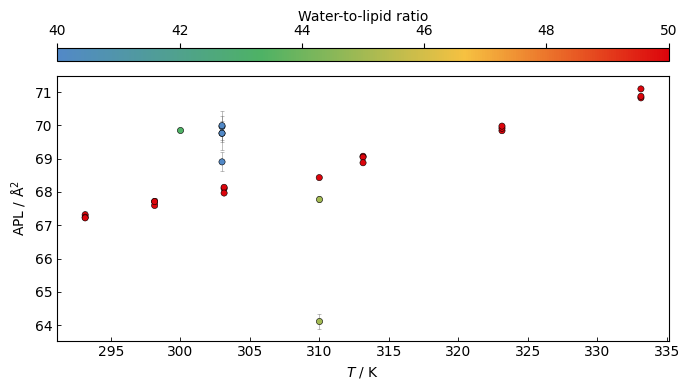

In [16]:
color_prop = "water_lipid_ratio"

fig, ax = plt.subplots(figsize=(7.0, 4))

df = df_records.query('is_single_component and is_equilibrated and lipid=="DOPC"')[
    ['ionic_strength','temperature','FF','APL','APL_err','solution_composition','n_lipids','water_lipid_ratio']]

norm = plt.Normalize(df[color_prop].dropna().min(), df[color_prop].dropna().max())

ax.errorbar(df["temperature"], df["APL"], yerr=df["APL_err"], fmt="none", ecolor="0.35", elinewidth=0.5, 
            capsize=1.5, capthick=0.5, alpha=0.55, zorder=2)

for ff, sub in df.dropna(subset=["temperature", "APL", color_prop, "FF"]).groupby("FF"):
    ax.scatter(sub["temperature"], sub["APL"], c=sub[color_prop], cmap=cmap, norm=norm, marker='o', 
               edgecolors="k", linewidth=0.4, s=20, zorder=10)

ax.tick_params(direction="in", length=3, width=0.6)
ax.set_xlabel(r"$T$ / K")
ax.set_ylabel(r"APL / $\mathrm{\AA^2}$")

#handles = [mlines.Line2D([], [], color="k", marker='o', linestyle="None", markersize=4, markerfacecolor="white", label=ff) for ff in sorted(df["FF"].dropna().unique())]
#ax.legend(handles=handles, loc="best", frameon=False, fontsize=6, handletextpad=0.3)

divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.15)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label('Water-to-lipid ratio', labelpad=2)
cax.xaxis.set_label_position("top")
cax.xaxis.set_ticks_position("top")
plt.tight_layout()
plt.savefig('DOPC_APL_vs_T.pdf')
plt.show()

### Correlation between compressibility modulus and temperature

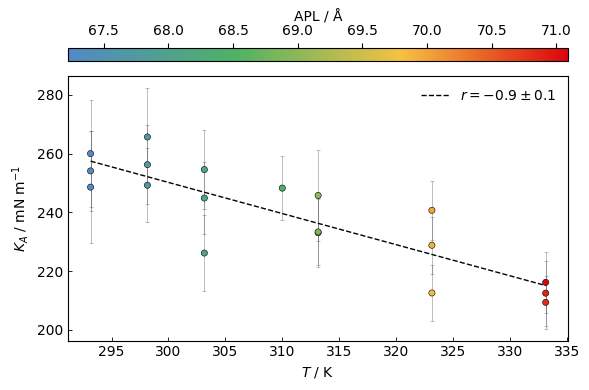

In [15]:
color_prop = "APL"

fig, ax = plt.subplots(figsize=(6.0, 4))

df = df_records.query('is_single_component and is_equilibrated and is_charmm and lipid=="DOPC"')[
    ['ionic_strength','temperature','FF','KA','KA_err','solution_composition','n_lipids','APL']]

norm = plt.Normalize(df[color_prop].dropna().min(), df[color_prop].dropna().max())

ax.errorbar(df["temperature"], df["KA"], yerr=df["KA_err"], fmt="none", ecolor="0.35", elinewidth=0.5, 
            capsize=1.5, capthick=0.5, alpha=0.55, zorder=2)

for ff, sub in df.dropna(subset=["temperature", "KA", color_prop, "FF"]).groupby("FF"):
    ax.scatter(sub["temperature"], sub["KA"], c=sub[color_prop], cmap=cmap, norm=norm, marker='o', 
               edgecolors="k", linewidth=0.4, s=20, zorder=10)

ax.tick_params(direction="in", length=3, width=0.6)
ax.set_xlabel(r"$T$ / K")
ax.set_ylabel(r"$K_A$ / mN m$^{-1}$")

r = pearsonr(df["temperature"], df["KA"]).statistic
rng = np.random.default_rng(42)
boot = np.array([pearsonr(df["temperature"].values[idx], df["KA"].values[idx]).statistic for idx in (rng.integers(0, len(df), len(df)) for _ in range(10000))])
r_lo, r_hi = np.nanpercentile(boot, [2.5, 97.5])
r_err = (r_hi - r_lo) / 2
slope, intercept = np.polyfit(df["temperature"], df["KA"], 1)
x_fit = np.linspace(df["temperature"].min(), df["temperature"].max(), 200)
ax.plot(x_fit, slope*x_fit + intercept, color='k', ls='--', lw=1, label=rf'$r={r:.1f}\pm{r_err:.1f}$')
ax.legend(frameon=False)
divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.15)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label('APL / Å', labelpad=2)
cax.xaxis.set_label_position("top")
cax.xaxis.set_ticks_position("top")

plt.tight_layout()
plt.savefig('DOPC_KA_vs_T.pdf')
plt.show()

### Correlation between compressibility modulus and area per lipid

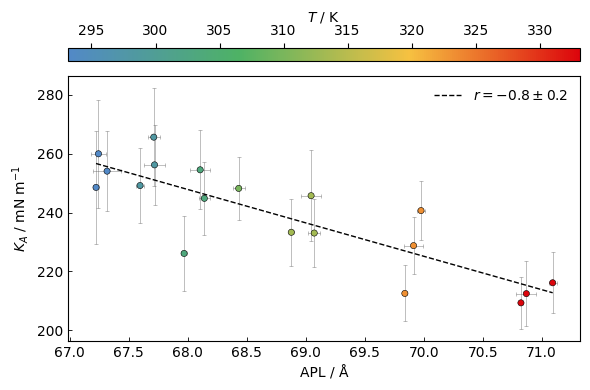

In [13]:
color_prop = "temperature"

fig, ax = plt.subplots(figsize=(6.0, 4))

df = df_records.query('is_single_component and is_equilibrated and is_charmm and lipid=="DOPC"')[
    ['ionic_strength','temperature','FF','KA','KA_err','solution_composition','n_lipids','APL','APL_err']]



norm = plt.Normalize(df[color_prop].dropna().min(), df[color_prop].dropna().max())

ax.errorbar(df["APL"], df["KA"], xerr=df["APL_err"], yerr=df["KA_err"], fmt="none", ecolor="0.35", elinewidth=0.5, 
            capsize=1.5, capthick=0.5, alpha=0.55, zorder=2)

for ff, sub in df.dropna(subset=["temperature", "KA", "APL", color_prop, "FF"]).groupby("FF"):
    ax.scatter(sub["APL"], sub["KA"], c=sub[color_prop], cmap=cmap, norm=norm, marker='o', 
               edgecolors="k", linewidth=0.4, s=20, zorder=10)

ax.tick_params(direction="in", length=3, width=0.6)
ax.set_xlabel('APL / Å')
ax.set_ylabel(r"$K_A$ / mN m$^{-1}$")

r = pearsonr(df["APL"], df["KA"]).statistic
rng = np.random.default_rng(42)
boot = np.array([pearsonr(df["APL"].values[idx], df["KA"].values[idx]).statistic for idx in (rng.integers(0, len(df), len(df)) for _ in range(10000))])
r_lo, r_hi = np.nanpercentile(boot, [2.5, 97.5])
r_err = (r_hi - r_lo) / 2
slope, intercept = np.polyfit(df["APL"], df["KA"], 1)
x_fit = np.linspace(df["APL"].min(), df["APL"].max(), 200)
ax.plot(x_fit, slope*x_fit + intercept, color='k', ls='--', lw=1, label=rf'$r={r:.1f}\pm{r_err:.1f}$')
ax.legend(frameon=False)
divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.15)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label(r"$T$ / K", labelpad=2)
cax.xaxis.set_label_position("top")
cax.xaxis.set_ticks_position("top")

plt.tight_layout()
plt.savefig('DOPC_KA_vs_APL.pdf')
plt.show()

### Correlation between compressibility modulus and cholesterol fraction

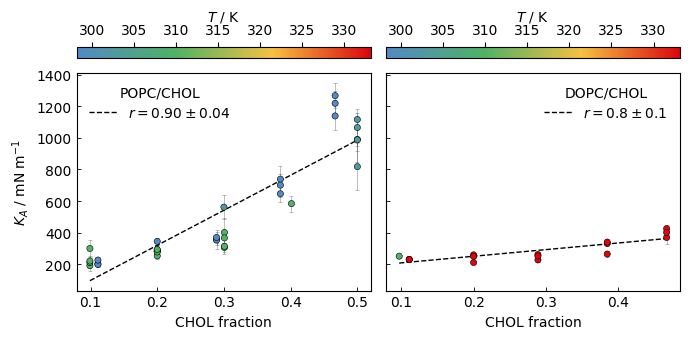

In [14]:
comp_2 = "CHOL"
color_prop = "temperature"

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5), sharey=True)

dfs = {}
for comp_1 in ["POPC", "DOPC"]:
    dfs[comp_1] = df_records[df_records["membrane_composition"].apply(lambda x: set(x.keys()) == {comp_1, comp_2})].query(
        'is_equilibrated and is_charmm')[['membrane_composition','ionic_strength',
        'temperature','FF','KA','KA_err','solution_composition','n_lipids','water_lipid_ratio']]

norm = plt.Normalize(
    min(df[color_prop].dropna().min() for df in dfs.values()),
    max(df[color_prop].dropna().max() for df in dfs.values())
)

for ax, comp_1 in zip(axs, ["POPC", "DOPC"]):
    df = dfs[comp_1]

    ax.errorbar(df["membrane_composition"].apply(lambda x: x[comp_2]), df["KA"], yerr=df["KA_err"],
                fmt="none", ecolor="0.35", elinewidth=0.5, capsize=1.5, capthick=0.5, alpha=0.55, zorder=2)

    ax.scatter(df["membrane_composition"].apply(lambda x: x[comp_2]), df["KA"],
               c=df[color_prop], cmap=cmap, norm=norm, marker="o",
               edgecolors="k", linewidth=0.4, s=20, zorder=10)

    ax.tick_params(direction="in", length=3, width=0.6)
    ax.set_xlabel(f"{comp_2} fraction")

    x = df["membrane_composition"].apply(lambda x: x[comp_2]).values
    y = df["KA"].values

    r = pearsonr(x, y).statistic
    rng = np.random.default_rng(42)
    boot = np.array([pearsonr(x[idx], y[idx]).statistic for idx in (rng.integers(0, len(df), len(df)) for _ in range(10000))])
    r_lo, r_hi = np.nanpercentile(boot, [2.5, 97.5])
    r_err = (r_hi - r_lo) / 2

    slope, intercept = np.polyfit(x, y, 1)
    x_fit = np.linspace(x.min(), x.max(), 200)

    if r_err > 0.1:
        ax.plot(x_fit, slope*x_fit + intercept, "k--", lw=1, label=rf"$r={r:.1f}\pm{r_err:.1f}$")
    else:
        ax.plot(x_fit, slope*x_fit + intercept, "k--", lw=1, label=rf"$r={r:.2f}\pm{r_err:.2f}$")

    ax.legend(title=f"{comp_1}/{comp_2}", frameon=False)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("top", size="5%", pad=0.15)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
    cb.set_label(r"$T$ / K", labelpad=2)
    cax.xaxis.set_label_position("top")
    cax.xaxis.set_ticks_position("top")

axs[0].set_ylabel(r"$K_A$ / mN m$^{-1}$")

plt.tight_layout()
plt.savefig("POPC_DOPC_CHOL_KA_vs_CHOL_fraction.pdf")
plt.show()

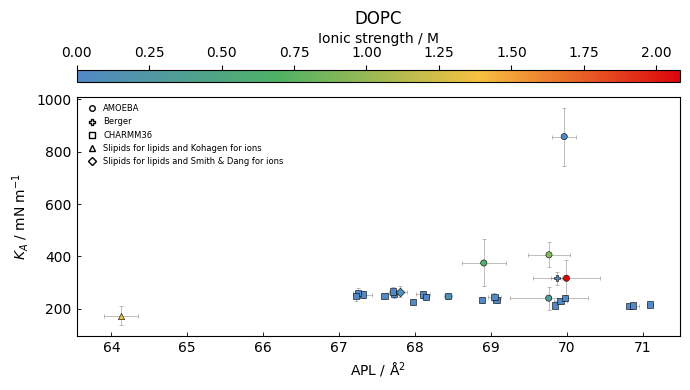

In [27]:
color_prop = "ionic_strength"

fig, ax = plt.subplots(figsize=(7.0, 4))

df = df_records.query('single_component and lipid == "DOPC" and is_equilibrated')[
    [color_prop,'temperature','FF','KA','KA_err','APL','APL_err','solution_composition','n_lipids']]

norm = plt.Normalize(df[color_prop].dropna().min(), df[color_prop].dropna().max())
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "x", "p", "+"]
marker_map = dict(zip(df['FF'].unique(), marker_cycle))

ax.errorbar(df["APL"], df["KA"], xerr=df["APL_err"], yerr=df["KA_err"], fmt="none", ecolor="0.35", elinewidth=0.5, capsize=1.5, capthick=0.5, alpha=0.55, zorder=2)

for ff, sub in df.dropna(subset=["KA", "APL", color_prop, "FF"]).groupby("FF"):
    ax.scatter(sub["APL"], sub["KA"], c=sub[color_prop], cmap=cmap, norm=norm, marker=marker_map[ff], edgecolors="k", linewidth=0.4, s=20, zorder=10)

ax.tick_params(direction="in", length=3, width=0.6)
ax.set_xlabel(r"APL / $\mathrm{\AA^2}$")
ax.set_ylabel(r"$K_A$ / mN m$^{-1}$")

handles = [mlines.Line2D([], [], color="k", marker=marker_map[ff], linestyle="None", markersize=4, markerfacecolor="white", label=ff) for ff in sorted(df["FF"].dropna().unique())]
ax.legend(handles=handles, loc="best", frameon=False, fontsize=6, handletextpad=0.3)

divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.15)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label("Ionic strength / M", labelpad=2)
cax.xaxis.set_label_position("top")
cax.xaxis.set_ticks_position("top")
plt.title('DOPC')
plt.tight_layout()
plt.savefig('DOPC_KA_vs_APL_Ionic.pdf')
plt.show()

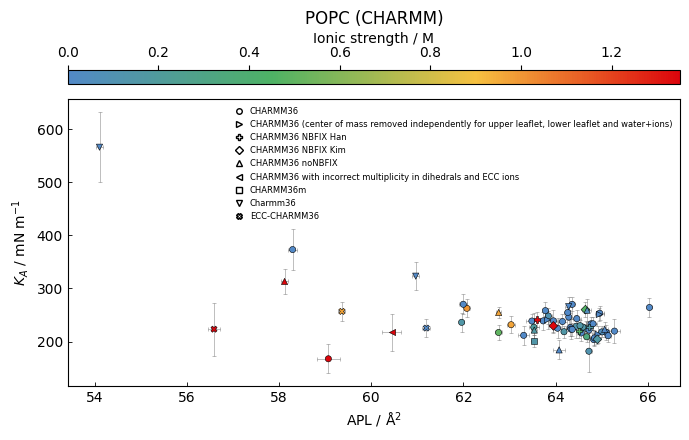

In [34]:
color_prop = "ionic_strength"

fig, ax = plt.subplots(figsize=(7.0, 4.5))

df = df_records.query('single_component and lipid == "POPC" and is_equilibrated and is_charmm')[
    [color_prop,'temperature','FF','KA','KA_err','APL','APL_err','solution_composition','n_lipids']]

norm = plt.Normalize(df[color_prop].dropna().min(), df[color_prop].dropna().max())
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "x", "p", "+"]
marker_map = dict(zip(df['FF'].unique(), marker_cycle))

ax.errorbar(df["APL"], df["KA"], xerr=df["APL_err"], yerr=df["KA_err"], fmt="none", ecolor="0.35", elinewidth=0.5, capsize=1.5, capthick=0.5, alpha=0.55, zorder=2)

for ff, sub in df.dropna(subset=["KA", "APL", color_prop, "FF"]).groupby("FF"):
    ax.scatter(sub["APL"], sub["KA"], c=sub[color_prop], cmap=cmap, norm=norm, marker=marker_map[ff], edgecolors="k", linewidth=0.4, s=20, zorder=10)

ax.tick_params(direction="in", length=3, width=0.6)
ax.set_xlabel(r"APL / $\mathrm{\AA^2}$")
ax.set_ylabel(r"$K_A$ / mN m$^{-1}$")

handles = [mlines.Line2D([], [], color="k", marker=marker_map[ff], linestyle="None", markersize=4, markerfacecolor="white", label=ff) for ff in sorted(df["FF"].dropna().unique())]
ax.legend(handles=handles, loc="best", frameon=False, fontsize=6, handletextpad=0.3)

divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.15)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label("Ionic strength / M", labelpad=2)
cax.xaxis.set_label_position("top")
cax.xaxis.set_ticks_position("top")
plt.title('POPC (CHARMM)')
plt.tight_layout()
plt.savefig('POPC_KA_vs_APL_Ionic.pdf')
plt.show()

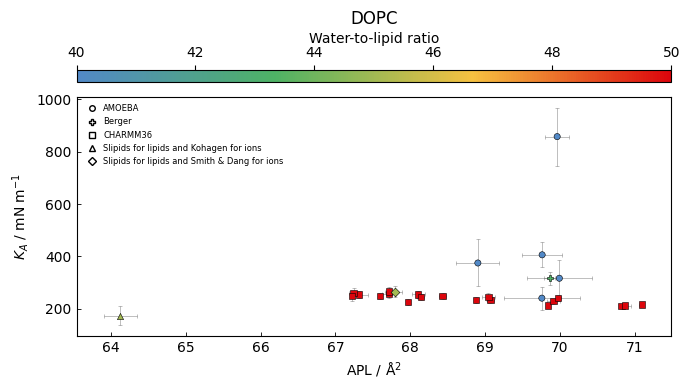

In [28]:
color_prop = "water_lipid_ratio"

fig, ax = plt.subplots(figsize=(7.0, 4))

df = df_records.query('single_component and lipid == "DOPC" and is_equilibrated')[
    [color_prop,'temperature','FF','KA','KA_err','APL','APL_err','solution_composition','n_lipids']]

norm = plt.Normalize(df[color_prop].dropna().min(), df[color_prop].dropna().max())
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "x", "p", "+"]
marker_map = dict(zip(df['FF'].unique(), marker_cycle))

ax.errorbar(df["APL"], df["KA"], xerr=df["APL_err"], yerr=df["KA_err"], fmt="none", ecolor="0.35", elinewidth=0.5, capsize=1.5, capthick=0.5, alpha=0.55, zorder=2)

for ff, sub in df.dropna(subset=["KA", "APL", color_prop, "FF"]).groupby("FF"):
    ax.scatter(sub["APL"], sub["KA"], c=sub[color_prop], cmap=cmap, norm=norm, marker=marker_map[ff], edgecolors="k", linewidth=0.4, s=20, zorder=10)

ax.tick_params(direction="in", length=3, width=0.6)
ax.set_xlabel(r"APL / $\mathrm{\AA^2}$")
ax.set_ylabel(r"$K_A$ / mN m$^{-1}$")

handles = [mlines.Line2D([], [], color="k", marker=marker_map[ff], linestyle="None", markersize=4, markerfacecolor="white", label=ff) for ff in sorted(df["FF"].dropna().unique())]
ax.legend(handles=handles, loc="best", frameon=False, fontsize=6, handletextpad=0.3)

divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.15)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label("Water-to-lipid ratio", labelpad=2)
cax.xaxis.set_label_position("top")
cax.xaxis.set_ticks_position("top")
plt.title('DOPC')
plt.tight_layout()
plt.savefig('DOPC_KA_vs_APL_W2L.pdf')
plt.show()

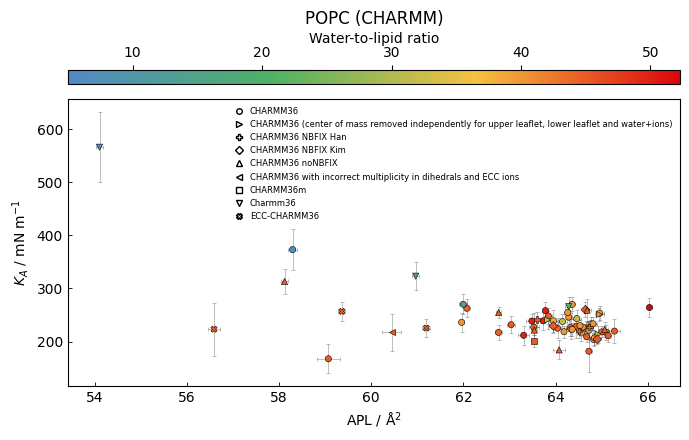

In [33]:
color_prop = "water_lipid_ratio"

fig, ax = plt.subplots(figsize=(7.0, 4.5))

df = df_records.query('single_component and lipid == "POPC" and is_equilibrated and is_charmm')[
    [color_prop,'temperature','FF','KA','KA_err','APL','APL_err','solution_composition','n_lipids']]

norm = plt.Normalize(df[color_prop].dropna().min(), df[color_prop].dropna().max())
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "x", "p", "+"]
marker_map = dict(zip(df['FF'].unique(), marker_cycle))

ax.errorbar(df["APL"], df["KA"], xerr=df["APL_err"], yerr=df["KA_err"], fmt="none", ecolor="0.35", elinewidth=0.5, capsize=1.5, capthick=0.5, alpha=0.55, zorder=2)

for ff, sub in df.dropna(subset=["KA", "APL", color_prop, "FF"]).groupby("FF"):
    ax.scatter(sub["APL"], sub["KA"], c=sub[color_prop], cmap=cmap, norm=norm, marker=marker_map[ff], edgecolors="k", linewidth=0.4, s=20, zorder=10)

ax.tick_params(direction="in", length=3, width=0.6)
ax.set_xlabel(r"APL / $\mathrm{\AA^2}$")
ax.set_ylabel(r"$K_A$ / mN m$^{-1}$")

handles = [mlines.Line2D([], [], color="k", marker=marker_map[ff], linestyle="None", markersize=4, markerfacecolor="white", label=ff) for ff in sorted(df["FF"].dropna().unique())]
ax.legend(handles=handles, loc="best", frameon=False, fontsize=6, handletextpad=0.3)

divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.15)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label("Water-to-lipid ratio", labelpad=2)
cax.xaxis.set_label_position("top")
cax.xaxis.set_ticks_position("top")
plt.title('POPC (CHARMM)')
plt.tight_layout()
plt.savefig('POPC_KA_vs_APL_W2L.pdf')
plt.show()